## **MACHINE LEARNING**
## **NAMA : DELLA MUSTIFAR**
## **NIM : F1G123043**
## **KELAS : C**

# **Implementasi dan Analisis Performa Algoritma Random Forest, Gradient Boosting, dan XGBoost dalam Model Regresi untuk Prediksi Harga Rumah**

### **A. Data Gathering**

Tahap mengambil dataset

### **1. Import Library**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from tabulate import tabulate

### **2. Load Dataset**

In [19]:
from google.colab import files
uploaded = files.upload()

Saving AmesHousing.csv to AmesHousing (1).csv


In [20]:
# Load dataset
df = pd.read_csv("AmesHousing.csv")

# CLEAN NAMA KOLOM
df.columns = df.columns.str.replace(" ", "")

# DI SINI LETAKNYA
features = ['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF', 'FullBath']

# Ambil data
X = df[features]
y = df['SalePrice']

### **B. Data Understanding**
Data understanding adalah tahap awal dalam proses Machine Learning di mana kita memahami isi, struktur, dan karakteristik data sebelum mulai membuat model.

In [21]:

# FIX NAMA KOLOM (PENTING BANGET)
df.columns = df.columns.str.replace(" ", "")

# ==========================================
# DATA UNDERSTANDING
# ==========================================
print("=== DATA AWAL ===")
print(df.head())

print("\n=== INFO DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

# ==========================================
# PREPROCESSING
# ==========================================

# 1. MISSING VALUE
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\n=== MISSING VALUE SELESAI ===")
print(df.isnull().sum().sum())

# ==========================================
# FEATURE ENGINEERING
# ==========================================
df['TotalSF'] = df['GrLivArea'] + df['TotalBsmtSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['TotalBathrooms'] = df['FullBath'] + (0.5 * df['HalfBath'])

# ==========================================
# HAPUS KOLOM TIDAK PENTING
# ==========================================
df = df.drop(['Order', 'PID'], axis=1)

# ==========================================
# OUTLIER REMOVAL (IQR)
# ==========================================
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['SalePrice', 'GrLivArea', 'TotalSF']:
    df = remove_outliers(df, col)

print("\n=== SHAPE SETELAH OUTLIER ===")
print(df.shape)

# ==========================================
# ENCODING
# ==========================================
df = pd.get_dummies(df, drop_first=True)

print("Jumlah fitur setelah encoding:", df.shape[1])

# ==========================================
# SPLIT DATA
# ==========================================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# MODELING
# ==========================================

# 1. RANDOM FOREST
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 2. GRADIENT BOOSTING
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# 3. XGBOOST
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# ==========================================
# EVALUASI
# ==========================================
def evaluate(y_test, y_pred, name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")
evaluate(y_test, y_pred_xgb, "XGBoost")

=== DATA AWAL ===
   Order        PID  MSSubClass MSZoning  LotFrontage  LotArea Street Alley  \
0      1  526301100          20       RL        141.0    31770   Pave   NaN   
1      2  526350040          20       RH         80.0    11622   Pave   NaN   
2      3  526351010          20       RL         81.0    14267   Pave   NaN   
3      4  526353030          20       RL         93.0    11160   Pave   NaN   
4      5  527105010          60       RL         74.0    13830   Pave   NaN   

  LotShape LandContour  ... PoolArea PoolQC  Fence MiscFeature MiscVal MoSold  \
0      IR1         Lvl  ...        0    NaN    NaN         NaN       0      5   
1      Reg         Lvl  ...        0    NaN  MnPrv         NaN       0      6   
2      IR1         Lvl  ...        0    NaN    NaN        Gar2   12500      6   
3      Reg         Lvl  ...        0    NaN    NaN         NaN       0      4   
4      IR1         Lvl  ...        0    NaN  MnPrv         NaN       0      3   

  YrSold SaleType  S

### **Exploratory Data Analysis (EDA)**

=== DISTRIBUSI DATA ===


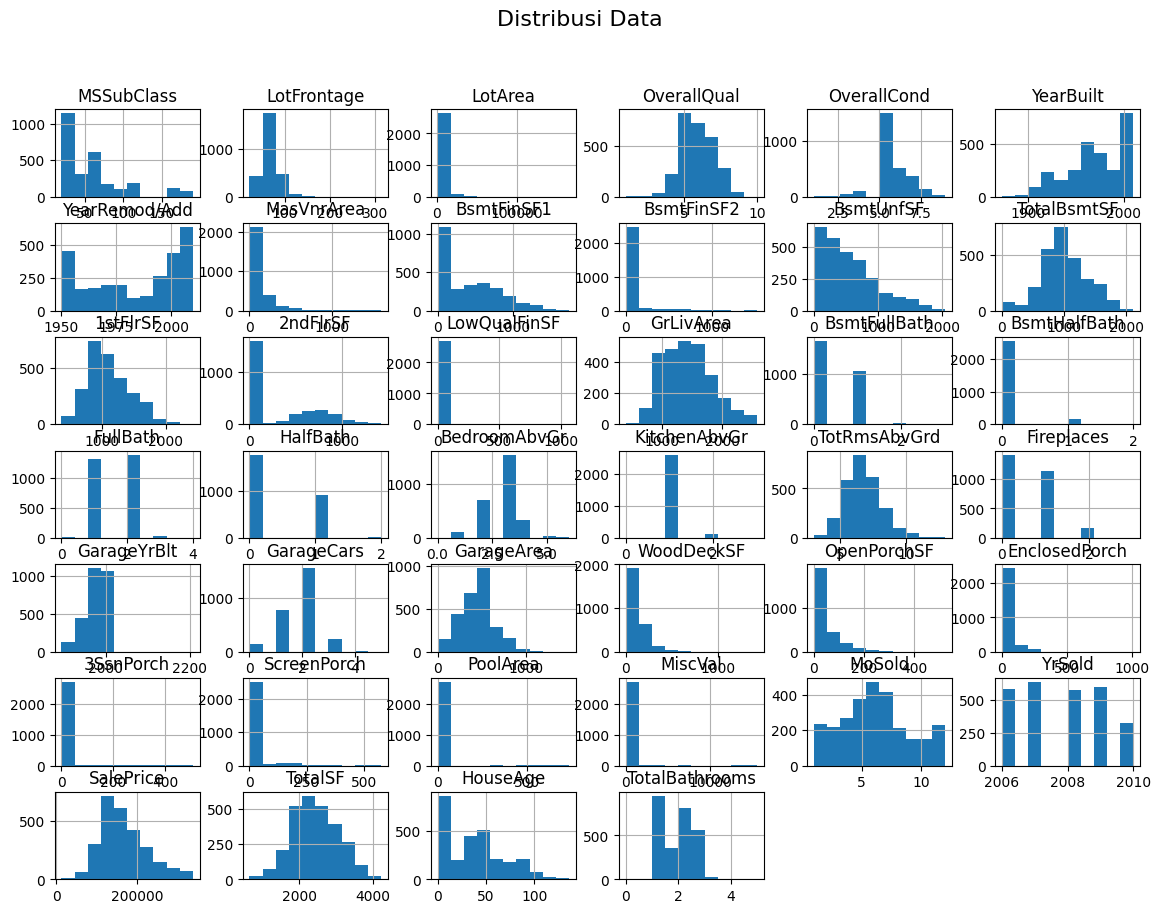

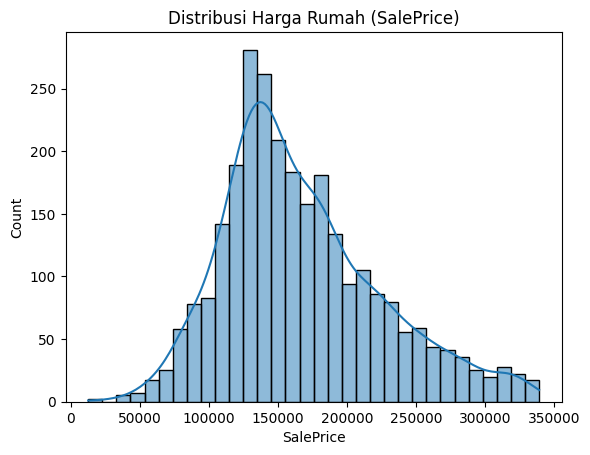


=== KORELASI ===


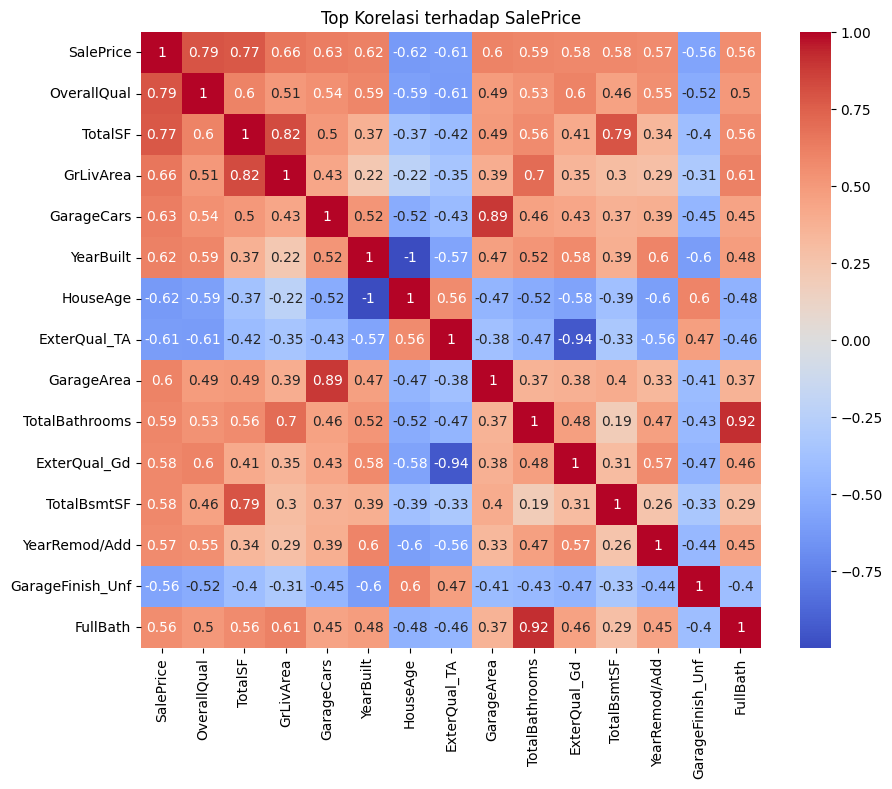

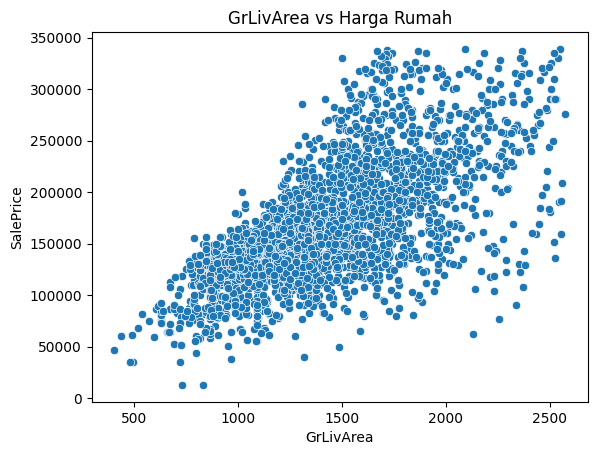

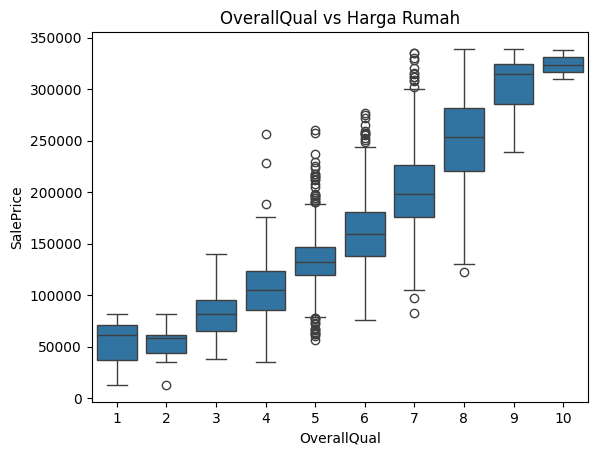

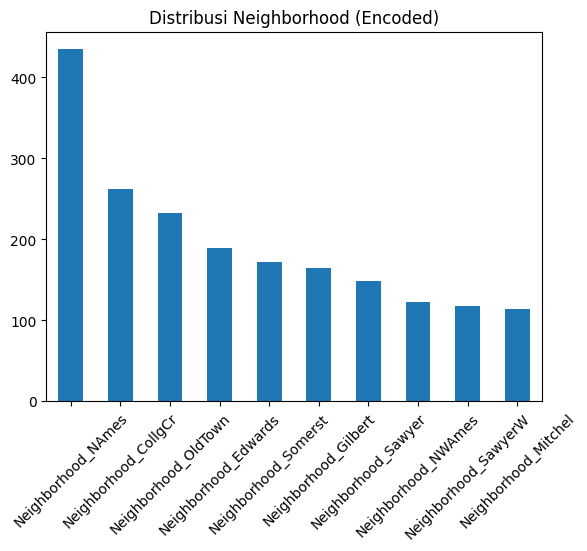

In [22]:
# ==========================================
# 1. DISTRIBUSI DATA
# ==========================================
print("=== DISTRIBUSI DATA ===")

df.hist(figsize=(14,10))
plt.suptitle("Distribusi Data", fontsize=16)
plt.show()

# ==========================================
# 2. DISTRIBUSI TARGET
# ==========================================
plt.figure()
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribusi Harga Rumah (SalePrice)")
plt.show()

# ==========================================
# 3. KORELASI (VERSI BAGUS )
# ==========================================
print("\n=== KORELASI ===")

corr = df.corr(numeric_only=True)

# Ambil TOP 15 fitur paling berpengaruh
top_features = corr['SalePrice'].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.title("Top Korelasi terhadap SalePrice")
plt.show()

# ==========================================
# 4. HUBUNGAN FITUR DENGAN TARGET
# ==========================================

# GrLivArea vs SalePrice
plt.figure()
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("GrLivArea vs Harga Rumah")
plt.show()

# OverallQual vs SalePrice
plt.figure()
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title("OverallQual vs Harga Rumah")
plt.show()

# ==========================================
# 5. ANALISIS KATEGORIKAL (SETELAH ENCODING)
# ==========================================

# Ambil semua kolom neighborhood hasil encoding
neigh_cols = [col for col in df.columns if "Neighborhood_" in col]

if len(neigh_cols) > 0:
    df[neigh_cols].sum().sort_values(ascending=False).head(10).plot(kind='bar')
    plt.title("Distribusi Neighborhood (Encoded)")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Kolom Neighborhood sudah tidak tersedia atau belum ada encoding")

**Data Splitting**

In [23]:
# ==========================================
# MENENTUKAN FITUR DAN TARGET
# ==========================================
X = df.drop('SalePrice', axis=1)  # fitur
y = df['SalePrice']              # target

# ==========================================
# VARIASI 1: 70% TRAIN - 30% TEST
# ==========================================
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("=== SPLIT 70:30 ===")
print("Train:", X_train1.shape)
print("Test :", X_test1.shape)

# ==========================================
# VARIASI 2: 80% TRAIN - 20% TEST
# ==========================================
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n=== SPLIT 80:20 ===")
print("Train:", X_train2.shape)
print("Test :", X_test2.shape)

# ==========================================
# VARIASI 3: 90% TRAIN - 10% TEST
# ==========================================
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print("\n=== SPLIT 90:10 ===")
print("Train:", X_train3.shape)
print("Test :", X_test3.shape)

=== SPLIT 70:30 ===
Train: (1908, 258)
Test : (819, 258)

=== SPLIT 80:20 ===
Train: (2181, 258)
Test : (546, 258)

=== SPLIT 90:10 ===
Train: (2454, 258)
Test : (273, 258)


# **Pemodelan**

In [24]:

# ==========================================
# CLEAN NAMA KOLOM (FIX XGBOOST)
# ==========================================
df.columns = df.columns.str.replace('[^A-Za-z0-9_]', '', regex=True)

# ==========================================
# SPLIT DATA (80:20)
# ==========================================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# MODEL BUILDING
# ==========================================

# RANDOM FOREST
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# GRADIENT BOOSTING
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# XGBOOST (PALING KUAT)
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# ==========================================
# EVALUASI
# ==========================================
def evaluate_model(y_test, y_pred, nama_model):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== {nama_model} ===")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

# ==========================================
# HASIL
# ==========================================
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_gb, "Gradient Boosting")
evaluate_model(y_test, y_pred_xgb, "XGBoost")


=== Random Forest ===
MAE : 13392.111892278563
MSE : 338922778.8520282
RMSE: 18409.85548156281
R2  : 0.8957905666488075

=== Gradient Boosting ===
MAE : 11952.590793543279
MSE : 257129045.98422375
RMSE: 16035.243870431897
R2  : 0.9209398899923238

=== XGBoost ===
MAE : 11772.322265625
MSE : 252555488.0
RMSE: 15891.994462621738
R2  : 0.9223461151123047


### **Hyperparameter Tuning**

In [25]:
# ==========================================
# IMPORT TAMBAHAN
# ==========================================
from sklearn.model_selection import RandomizedSearchCV

# ==========================================
# RANDOM FOREST TUNING
# ==========================================
rf_param = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)

# ==========================================
# GRADIENT BOOSTING TUNING
# ==========================================
gb_param = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

gb_search.fit(X_train, y_train)
gb_best = gb_search.best_estimator_
y_pred_gb = gb_best.predict(X_test)

# ==========================================
# XGBOOST TUNING (PALING PENTING)
# ==========================================
xgb_param = {
    'n_estimators': [300, 500, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_param,
    n_iter=15,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)

# ==========================================
# EVALUASI SETELAH TUNING
# ==========================================
def evaluate(y_test, y_pred, name):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

evaluate(y_test, y_pred_rf, "Random Forest (Tuning)")
evaluate(y_test, y_pred_gb, "Gradient Boosting (Tuning)")
evaluate(y_test, y_pred_xgb, "XGBoost (Tuning)")


=== Random Forest (Tuning) ===
MAE : 13608.566146425868
MSE : 345138494.6095494
RMSE: 18577.903396496316
R2  : 0.8938794049996635

=== Gradient Boosting (Tuning) ===
MAE : 11752.32524156114
MSE : 251787970.70490542
RMSE: 15867.82816597487
R2  : 0.9225821237490193

=== XGBoost (Tuning) ===
MAE : 11443.123046875
MSE : 241614192.0
RMSE: 15543.943901082504
R2  : 0.9257102608680725


### **Evaluasi**

In [37]:
# ==========================================
# FUNGSI EVALUASI MODEL
# ==========================================
def evaluate_model(y_true, y_pred, nama_model, tipe_data):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {nama_model} ({tipe_data}) ===")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


# ==========================================
# PREDIKSI TRAIN
# ==========================================
y_train_pred_rf = rf.predict(X_train)
y_train_pred_gb = gb.predict(X_train)
y_train_pred_xgb = xgb.predict(X_train)

# ==========================================
# PREDIKSI TEST
# ==========================================
y_test_pred_rf = rf.predict(X_test)
y_test_pred_gb = gb.predict(X_test)
y_test_pred_xgb = xgb.predict(X_test)

# ==========================================
# EVALUASI TRAIN
# ==========================================
print("\n===== TRAIN PERFORMANCE =====")
rf_train_metrics = evaluate_model(y_train, y_train_pred_rf, "Random Forest", "Train")
gb_train_metrics = evaluate_model(y_train, y_train_pred_gb, "Gradient Boosting", "Train")
xgb_train_metrics = evaluate_model(y_train, y_train_pred_xgb, "XGBoost", "Train")

# ==========================================
# EVALUASI TEST
# ==========================================
print("\n===== TEST PERFORMANCE =====")
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf, "Random Forest", "Test")
gb_test_metrics = evaluate_model(y_test, y_test_pred_gb, "Gradient Boosting", "Test")
xgb_test_metrics = evaluate_model(y_test, y_test_pred_xgb, "XGBoost", "Test")


# ==========================================
# ANALISIS OVERFITTING / UNDERFITTING
# ==========================================
def analisis_overfitting(train_metrics, test_metrics, nama_model):
    print(f"\n--- Analisis {nama_model} ---")

    r2_train = train_metrics["R2"]
    r2_test = test_metrics["R2"]
    gap = r2_train - r2_test

    print(f"R2 Train: {r2_train}")
    print(f"R2 Test : {r2_test}")
    print(f"Gap     : {gap}")

    if r2_train > 0.9 and r2_test < 0.7:
        print("⚠️ Overfitting (model terlalu menghafal data train)")
    elif r2_train < 0.7 and r2_test < 0.7:
        print("⚠️ Underfitting (model kurang belajar)")
    else:
        print("✅ Model cukup baik (generalisasi bagus)")


# ==========================================
# JALANKAN ANALISIS
# ==========================================
analisis_overfitting(rf_train_metrics, rf_test_metrics, "Random Forest")
analisis_overfitting(gb_train_metrics, gb_test_metrics, "Gradient Boosting")
analisis_overfitting(xgb_train_metrics, xgb_test_metrics, "XGBoost")


===== TRAIN PERFORMANCE =====

=== Random Forest (Train) ===
MAE : 4994.308283563896
MSE : 52267379.1118753
RMSE: 7229.618185760248
R2  : 0.9842034677511827

=== Gradient Boosting (Train) ===
MAE : 5202.616512271368
MSE : 44676023.254263155
RMSE: 6684.012511528023
R2  : 0.9864977687024576

=== XGBoost (Train) ===
MAE : 1946.0665283203125
MSE : 6651600.0
RMSE: 2579.069599681249
R2  : 0.9979897141456604

===== TEST PERFORMANCE =====

=== Random Forest (Test) ===
MAE : 13392.111892278563
MSE : 338922778.8520282
RMSE: 18409.85548156281
R2  : 0.8957905666488075

=== Gradient Boosting (Test) ===
MAE : 11952.590793543279
MSE : 257129045.98422375
RMSE: 16035.243870431897
R2  : 0.9209398899923238

=== XGBoost (Test) ===
MAE : 11772.322265625
MSE : 252555488.0
RMSE: 15891.994462621738
R2  : 0.9223461151123047

--- Analisis Random Forest ---
R2 Train: 0.9842034677511827
R2 Test : 0.8957905666488075
Gap     : 0.08841290110237521
✅ Model cukup baik (generalisasi bagus)

--- Analisis Gradient Boost

**Berdasarkan hasil evaluasi, ketiga model yaitu Random Forest, Gradient Boosting, dan XGBoost menunjukkan performa yang baik dengan nilai R² pada data uji di atas 0.89. Tidak ditemukan indikasi overfitting yang signifikan karena selisih performa antara data latih dan data uji relatif kecil.**

**Dari ketiga model tersebut, XGBoost memberikan performa terbaik dengan tingkat akurasi tertinggi dan nilai error terendah, sehingga dipilih sebagai model yang paling optimal untuk prediksi harga rumah.**


In [30]:
pip install tabulate

In [33]:
# ==========================================
# TABEL EVALUASI (LENGKAP: MAE, MSE, RMSE, R2)
# ==========================================

evaluation_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],

    # =====================
    # TRAIN
    # =====================
    "MAE Train": [
        rf_train_metrics["MAE"],
        gb_train_metrics["MAE"],
        xgb_train_metrics["MAE"]
    ],
    "MSE Train": [
        rf_train_metrics["MSE"],
        gb_train_metrics["MSE"],
        xgb_train_metrics["MSE"]
    ],
    "RMSE Train": [
        rf_train_metrics["RMSE"],
        gb_train_metrics["RMSE"],
        xgb_train_metrics["RMSE"]
    ],
    "R2 Train": [
        rf_train_metrics["R2"],
        gb_train_metrics["R2"],
        xgb_train_metrics["R2"]
    ],

    # =====================
    # TEST
    # =====================
    "MAE Test": [
        rf_test_metrics["MAE"],
        gb_test_metrics["MAE"],
        xgb_test_metrics["MAE"]
    ],
    "MSE Test": [
        rf_test_metrics["MSE"],
        gb_test_metrics["MSE"],
        xgb_test_metrics["MSE"]
    ],
    "RMSE Test": [
        rf_test_metrics["RMSE"],
        gb_test_metrics["RMSE"],
        xgb_test_metrics["RMSE"]
    ],
    "R2 Test": [
        rf_test_metrics["R2"],
        gb_test_metrics["R2"],
        xgb_test_metrics["R2"]
    ],
})

print("\n=== TABEL EVALUASI MODEL ===")
print(tabulate(evaluation_df.round(3), headers='keys', tablefmt='grid'))


=== TABEL EVALUASI MODEL ===
+----+-------------------+-------------+-------------+--------------+------------+------------+-------------+-------------+-----------+
|    | Model             |   MAE Train |   MSE Train |   RMSE Train |   R2 Train |   MAE Test |    MSE Test |   RMSE Test |   R2 Test |
+====+===================+=============+=============+==============+============+============+=============+=============+===========+
|  0 | Random Forest     |     4994.31 | 5.22674e+07 |      7229.62 |      0.984 |    13392.1 | 3.38923e+08 |     18409.9 |     0.896 |
+----+-------------------+-------------+-------------+--------------+------------+------------+-------------+-------------+-----------+
|  1 | Gradient Boosting |     5202.62 | 4.4676e+07  |      6684.01 |      0.986 |    11952.6 | 2.57129e+08 |     16035.2 |     0.921 |
+----+-------------------+-------------+-------------+--------------+------------+------------+-------------+-------------+-----------+
|  2 | XGBoost    

### **Model Comparison**


=== MODEL COMPARISON ===
               Model  Split        MAE           MSE       RMSE     R2  Rank
8            XGBoost  90:10  11049.538  2.322547e+08  15239.906  0.930   1.0
7  Gradient Boosting  90:10  11429.806  2.559177e+08  15997.428  0.923   2.0
5            XGBoost  80:20  11772.322  2.525555e+08  15891.994  0.922   3.0
4  Gradient Boosting  80:20  11838.385  2.604001e+08  16136.919  0.920   4.0
2            XGBoost  70:30  12193.609  3.058594e+08  17488.835  0.912   5.0
1  Gradient Boosting  70:30  12393.632  3.073202e+08  17530.549  0.911   6.0
6      Random Forest  90:10  12647.554  2.997114e+08  17312.175  0.910   7.0
3      Random Forest  80:20  13385.464  3.390259e+08  18412.655  0.896   8.0
0      Random Forest  70:30  13811.075  3.738599e+08  19335.457  0.892   9.0


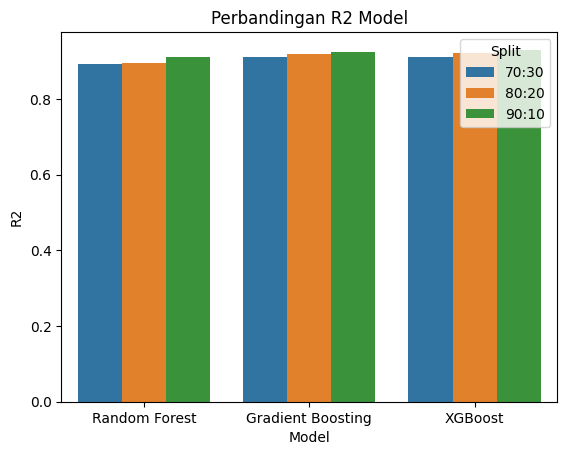

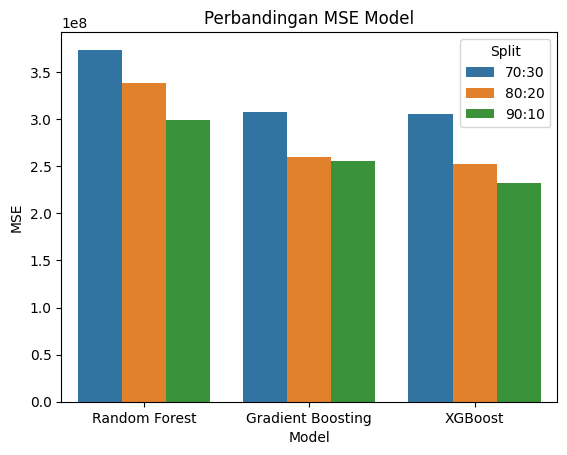

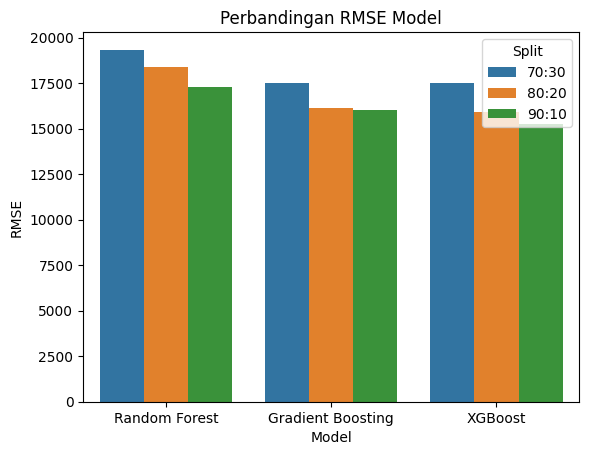

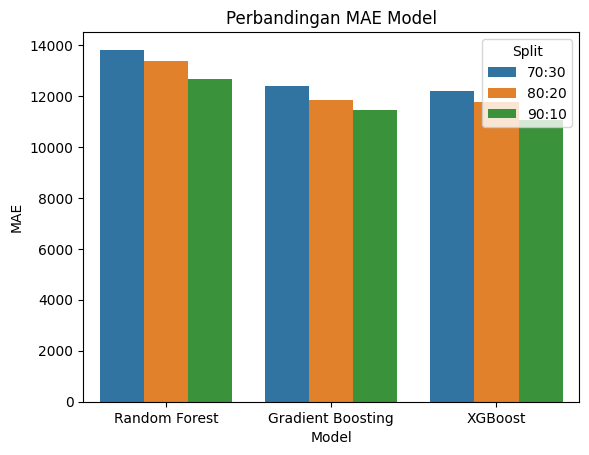


=== RANKING MODEL TERBAIK ===
+----+-------------------+---------+---------+-------------+---------+-------+--------+
|    | Model             | Split   |     MAE |         MSE |    RMSE |    R2 |   Rank |
+====+===================+=========+=========+=============+=========+=======+========+
|  8 | XGBoost           | 90:10   | 11049.5 | 2.32255e+08 | 15239.9 | 0.93  |      1 |
+----+-------------------+---------+---------+-------------+---------+-------+--------+
|  7 | Gradient Boosting | 90:10   | 11429.8 | 2.55918e+08 | 15997.4 | 0.923 |      2 |
+----+-------------------+---------+---------+-------------+---------+-------+--------+
|  5 | XGBoost           | 80:20   | 11772.3 | 2.52555e+08 | 15892   | 0.922 |      3 |
+----+-------------------+---------+---------+-------------+---------+-------+--------+
|  4 | Gradient Boosting | 80:20   | 11838.4 | 2.604e+08   | 16136.9 | 0.92  |      4 |
+----+-------------------+---------+---------+-------------+---------+-------+--------+
|

In [35]:
# ==========================================
# FUNCTION EVALUASI SEMUA MODEL
# ==========================================
def evaluate_all_models(X, y, split_ratio, split_name):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split_ratio, random_state=42
    )

    results = []

    models = {
        "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
        "XGBoost": XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "Model": name,
            "Split": split_name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        })

    return results


# ==========================================
# SIAPKAN DATA
# ==========================================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# OPTIONAL
# y = np.log1p(y)

# ==========================================
# JALANKAN SEMUA SPLIT
# ==========================================
all_results = []
all_results += evaluate_all_models(X, y, 0.3, "70:30")
all_results += evaluate_all_models(X, y, 0.2, "80:20")
all_results += evaluate_all_models(X, y, 0.1, "90:10")

# ==========================================
# DATAFRAME HASIL
# ==========================================
df_results = pd.DataFrame(all_results)

# Ranking (R2 tertinggi terbaik)
df_results['Rank'] = df_results['R2'].rank(ascending=False)

# Sorting terbaik
df_sorted = df_results.sort_values(by="R2", ascending=False)

# ==========================================
# TABEL BIASA
# ==========================================
print("\n=== MODEL COMPARISON ===")
print(df_sorted.round(3))

# ==========================================
# VISUALISASI
# ==========================================
plt.figure()
sns.barplot(x="Model", y="R2", hue="Split", data=df_results)
plt.title("Perbandingan R2 Model")
plt.show()

plt.figure()
sns.barplot(x="Model", y="MSE", hue="Split", data=df_results)
plt.title("Perbandingan MSE Model")
plt.show()

plt.figure()
sns.barplot(x="Model", y="RMSE", hue="Split", data=df_results)
plt.title("Perbandingan RMSE Model")
plt.show()

plt.figure()
sns.barplot(x="Model", y="MAE", hue="Split", data=df_results)
plt.title("Perbandingan MAE Model")
plt.show()

# ==========================================
# RANKING FINAL
# ==========================================
print("\n=== RANKING MODEL TERBAIK ===")
print(tabulate(df_sorted.round(3), headers='keys', tablefmt='grid'))